In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

# Data inspection and train test split

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 249 to 102
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   400 non-null    float64
 1   Time on App           400 non-null    float64
 2   Time on Website       400 non-null    float64
 3   Length of Membership  400 non-null    float64
dtypes: float64(4)
memory usage: 15.6 KB


array([[<Axes: title={'center': 'Avg. Session Length'}>,
        <Axes: title={'center': 'Time on App'}>],
       [<Axes: title={'center': 'Time on Website'}>,
        <Axes: title={'center': 'Length of Membership'}>]], dtype=object)

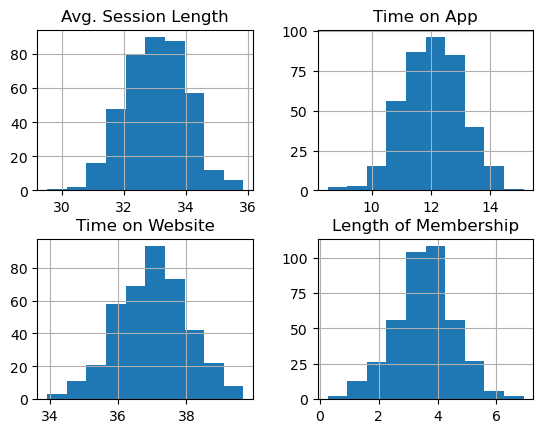

In [39]:
ecommerce = pd.read_csv("../data/ecommerce.csv")
X = ecommerce.drop(["Email", "Address", "Avatar", "Yearly Amount Spent"], axis=1)
y = ecommerce["Yearly Amount Spent"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.info()
X_train.hist() # all features distributions are symmetric

# Preprocessing and model selection

In [37]:
num_pipeline = make_pipeline(
    StandardScaler()
)
preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64"]).columns)
])

pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", Ridge())
]
)

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=5
)


grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_model.named_steps["model"].coef_

array([25.24050216, 38.69448252,  0.30581982, 63.53359105])

# Evaluation

Test R2: 0.9778155618342972
Test MSE: 109.85136722502119
Test RMSE: 10.481000296966945
Test MAE: 8.557805798317295


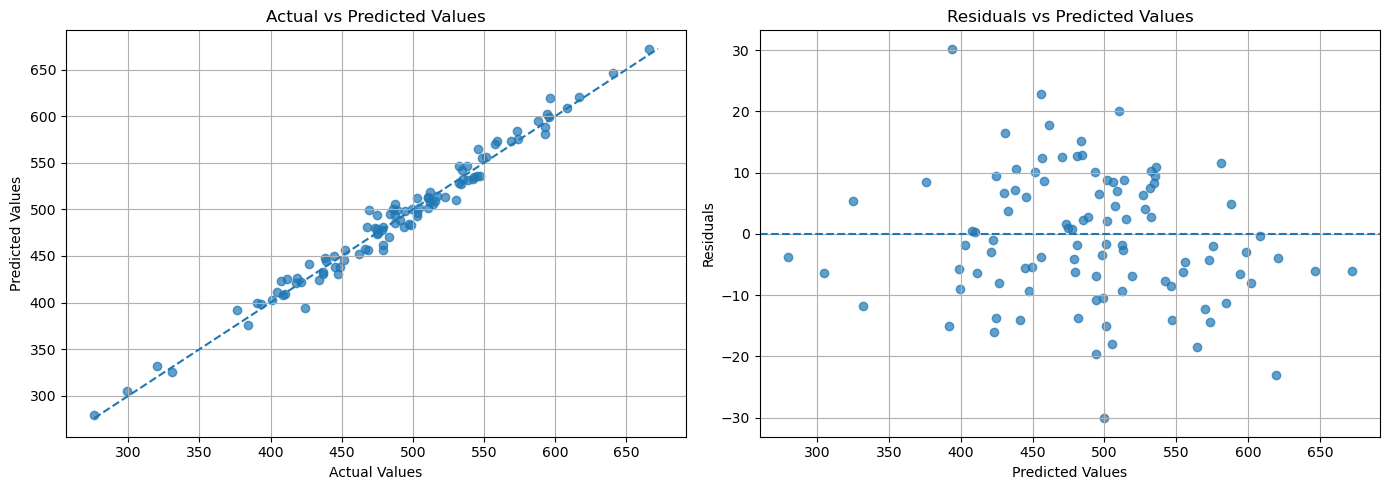

In [36]:
# we choose Lasso after our evaluations
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Values")
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].grid(True)

plt.tight_layout()
plt.show()
